# Fig 2 — accuracy & compute efficiency on Xenium

Reproduces **Fig2** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Fig 2 accuracy — paths & style
**🟢 light (reads caches)** · source: `fig2b_benchmark.ipynb cell 3`

In [ ]:
# === Paths (絶対パスで固定) ===
import matplotlib as mpl
import shutil
import subprocess

BENCH_DIR = BENCHMARK_DB
PRIMARY_TEST = BENCH_DIR / 'adata_hvg_test.h5ad'
PRIMARY_TRAIN = BENCH_DIR / 'adata_hvg_train.h5ad'
PRIMARY_GENES = BENCH_DIR / 'adata_hvg_genes.txt'

XENIUM_CONCAT = DATA_ROOT / 'GxD_xenium_concat_filtered_sample_split.h5ad'
LIVER_ANNOT   = BACKUP_ROOT / 'Liver.Step5_InSitu.TotalPC20Only.Major2.meta.info.txt'
# (removed) LUNG_ANNOT_H5AD — old single-sample 1-5 path; lung met test now uses
# gxd_split_config.load_lung_met(test_samples=LUNG_MET_TEST) per cell 9.

SPATNIC_WEIGHTS    = Path.home() / '.spatnic' / 'weights'
SPATNIC_MODELS_DIR = MODELS  # new met models
CKPT_PRIMARY = SPATNIC_WEIGHTS / 'tumor_normal.pt'
CKPT_LIVER   = SPATNIC_MODELS_DIR / 'tumor_normal_liver_met.pt'       # NEW (sample-level split)
CKPT_LUNG    = SPATNIC_MODELS_DIR / 'tumor_normal_lung_met__test9-4.pt'        # NEW (sample-level split)

CANCERFINDER_REPO = Path.home() / 'SequencingCancerFinder'

# === Output ===
OUT_DIR   = (COMP / 'fig2b')
WORK_DIR  = OUT_DIR / 'work'
SCORE_DIR = OUT_DIR / 'scores'
VAL_DIR   = OUT_DIR / 'val'   # cached val h5ad per organ
for d in [OUT_DIR, WORK_DIR, SCORE_DIR, VAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('OUT_DIR  =', OUT_DIR)

# === Reproducibility ===
SEED = 42
np.random.seed(SEED)

# === Labels & palette ===
POS, NEG = 'Tumor', 'Normal'
PALETTE = {
    'SPATNIC':           '#D55E00',
    'CancerFinder':      '#0072B2',
    'scMalignantFinder': '#009E73',
    'ikarus':            '#CC79A7',
}
ORGAN_ORDER = ['primary', 'liver', 'lung']
VARIANT_ORDER = ['default', 'retrained']

# === Conda envs (既存ノートブックと共通) ===
ENVS = {'scmalignant': 'scmalignant', 'ikarus': 'scmalignant', 'cancerfinder': 'scf'}
CONDA_BIN = shutil.which('conda') or str(Path.home() / 'miniconda3/bin/conda')
SUBPROC_ENV = {**os.environ, 'MPLBACKEND': 'Agg', 'PYTHONNOUSERSITE': '1'}
SUBPROC_ENV.pop('PYTHONPATH', None)

# === Publication style ===
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'figure.dpi': 120,
})

### Fig 2 accuracy — master common functions
**🟢 light (reads caches)** · source: `fig2b_benchmark.ipynb cell 5`

In [ ]:
# ============================================================
# MASTER common functions for Fig 2 notebooks
# Source: fig2b_benchmark.ipynb
# ============================================================
from scipy import stats as sst
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, matthews_corrcoef,
)

# ---------- Metrics ----------
def cell_metrics(y_true, score_pos, threshold=0.5):
    """Return dict of AUC-PR, AUC-ROC, F1, MCC for binary task (y_true: 'Tumor'/'Normal')."""
    y = (np.asarray(y_true) == POS).astype(int)
    s = np.asarray(score_pos, dtype=float)
    valid = ~np.isnan(s)
    y, s = y[valid], s[valid]
    out = {'n_cells': int(len(y)), 'n_pos': int(y.sum()), 'n_neg': int((1 - y).sum())}
    if out['n_pos'] == 0 or out['n_neg'] == 0:
        return {**out, 'auc_pr': np.nan, 'auc_roc': np.nan, 'f1': np.nan, 'mcc': np.nan}
    pred = (s >= threshold).astype(int)
    return {**out,
            'auc_pr':  float(average_precision_score(y, s)),
            'auc_roc': float(roc_auc_score(y, s)),
            'f1':      float(f1_score(y, pred)),
            'mcc':     float(matthews_corrcoef(y, pred))}


def per_sample_metrics(df, *, sample_col='sample', y_col='y_true',
                       score_col='score_tumor', threshold=0.5):
    """Compute cell_metrics per sample. Returns DataFrame indexed by sample."""
    rows = {}
    for s, g in df.groupby(sample_col):
        rows[s] = cell_metrics(g[y_col].values, g[score_col].values, threshold)
    out = pd.DataFrame.from_dict(rows, orient='index')
    out.index.name = sample_col
    return out


# ---------- Paired test ----------
def paired_wilcoxon(df_metrics, *, metric='auc_pr', method_col='method',
                    sample_col='sample', reference='SPATNIC'):
    """Sample-paired Wilcoxon signed-rank for SPATNIC vs each method.
    df_metrics is long-form: columns = [sample, method, metric]."""
    pivot = df_metrics.pivot(index=sample_col, columns=method_col, values=metric)
    ref = pivot[reference]
    out = []
    for m in pivot.columns:
        if m == reference:
            continue
        common = pivot[[reference, m]].dropna()
        if len(common) < 3:
            out.append({'method': m, 'n_pairs': len(common),
                        'median_ref': common[reference].median() if len(common) else np.nan,
                        'median_other': common[m].median() if len(common) else np.nan,
                        'stat': np.nan, 'p': np.nan})
            continue
        r = sst.wilcoxon(common[reference], common[m],
                          alternative='greater', zero_method='wilcox')
        out.append({'method': m, 'n_pairs': len(common),
                    'median_ref': float(common[reference].median()),
                    'median_other': float(common[m].median()),
                    'stat': float(r.statistic), 'p': float(r.pvalue)})
    res = pd.DataFrame(out)
    return res    # raw p only (no multiple-testing correction)


# ---------- Score I/O ----------
def score_path(organ: str, method: str, variant: str) -> Path:
    return SCORE_DIR / f'{organ}_{method}_{variant}.parquet'

def save_scores(df, organ, method, variant):
    p = score_path(organ, method, variant)
    df = df[['cell_id', 'sample', 'y_true', 'score_tumor', 'y_pred']].copy()
    df.to_parquet(p, index=False)
    print(f'[saved] {p}  ({len(df):,} cells)')
    return p

def load_scores(organ, method, variant):
    p = score_path(organ, method, variant)
    return pd.read_parquet(p) if p.exists() else None


# ---------- Subprocess helper ----------
def run_in_env(env: str, script: str, cwd: Path = None):
    """Run a Python script in a conda env, streaming output."""
    cwd = cwd or WORK_DIR
    cwd.mkdir(parents=True, exist_ok=True)
    return subprocess.run(
        [CONDA_BIN, 'run', '-n', env, '--no-capture-output', 'python', '-c', script],
        cwd=str(cwd), check=False, text=True, env=SUBPROC_ENV,
    )


# ---------- Plot helpers ----------
def hatch_for(variant):
    return '' if variant == 'default' else '////'

def alpha_for(variant):
    return 0.55 if variant == 'default' else 1.0

print('common functions ready')


def should_skip_score(score_p, val_h5ad):
    """Skip a baseline run only if the score parquet is NEWER than the val h5ad
    used to compute it. If val was rebuilt (e.g. new split), score is stale →
    re-run automatically. Set env GXD_FORCE_REBUILD=1 to ignore caches."""
    import os
    if os.environ.get('GXD_FORCE_REBUILD'):
        return False
    if not score_p.exists():
        return False
    try:
        return score_p.stat().st_mtime > Path(val_h5ad).stat().st_mtime
    except OSError:
        return False



def _bh_adjust(pvals):
    """Benjamini-Hochberg FDR adjusted p-values. NaN-safe."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    valid = ~np.isnan(p)
    if valid.sum() == 0:
        return out
    pv = p[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranks = np.empty(n, dtype=int)
    ranks[order] = np.arange(1, n + 1)
    q = pv * n / ranks                       # raw BH per rank
    q_sorted = q[order].astype(float)
    for i in range(n - 2, -1, -1):           # step-up monotonicity
        if q_sorted[i] > q_sorted[i + 1]:
            q_sorted[i] = q_sorted[i + 1]
    q_adj = np.empty(n)
    q_adj[order] = q_sorted
    out[valid] = np.clip(q_adj, 0, 1)
    return out

### Fig 2 accuracy — collect_metrics (reads score parquets)
**🟢 light (reads caches)** · source: `fig2b_benchmark.ipynb cell 23`

In [ ]:
METHODS = ['SPATNIC', 'CancerFinder', 'scMalignantFinder', 'ikarus']
VARIANTS_BY_METHOD = {
    'SPATNIC':           ['default'],          # primary は default 扱い、liver/lung は ft (single variant)
    'CancerFinder':      ['default', 'retrained'],
    'scMalignantFinder': ['default', 'retrained'],
    'ikarus':            ['default', 'retrained'],
}

def collect_metrics():
    rows_sample, rows_overall = [], []
    for organ in ORGAN_ORDER:
        for method in METHODS:
            for variant in VARIANTS_BY_METHOD[method]:
                # SPATNIC は retrained 概念がなく organ ごとに別 ckpt → file lookup は default で代表
                df = load_scores(organ, method, variant)
                if df is None and method == 'SPATNIC':
                    df = load_scores(organ, method, 'retrained')
                if df is None:
                    continue
                # per-sample
                ps = per_sample_metrics(df)
                ps['organ']   = organ
                ps['method']  = method
                ps['variant'] = variant
                ps['sample']  = ps.index
                rows_sample.append(ps.reset_index(drop=True))
                # overall
                ov = cell_metrics(df['y_true'].values, df['score_tumor'].values)
                ov.update({'organ': organ, 'method': method, 'variant': variant})
                rows_overall.append(ov)
    df_sample  = pd.concat(rows_sample, ignore_index=True) if rows_sample else pd.DataFrame()
    df_overall = pd.DataFrame(rows_overall)
    if len(df_sample):
        df_sample.to_parquet(OUT_DIR / 'metrics_per_sample.parquet', index=False)
    if len(df_overall):
        df_overall.to_parquet(OUT_DIR / 'metrics_overall.parquet', index=False)
    print(f'per-sample rows : {len(df_sample)}')
    print(f'overall rows    : {len(df_overall)}')
    return df_sample, df_overall

df_sample, df_overall = collect_metrics()
df_overall.head() if len(df_overall) else 'no scores yet'

### Fig 2 accuracy — plot_fig2b def (+3-organ call)
**🟢 light (reads caches)** · source: `fig2b_benchmark.ipynb cell 27`

In [ ]:
# Fig 2b — grouped bar plot
# Style: compare_with_other_tools_metastasis.ipynb 最終 figure を踏襲
#   * Primary / Liver / Lung を 3 パネル横並び
#   * method × variant の 7 系列をグループ縦棒
#   * per-sample 平均 ± SEM + Wilcoxon signed-rank (paired by sample, Bonferroni) vs SPATNIC
#   * N<3 の組織は bar のみ (検定なし)
#   * 大フォント、凡例は右外側
#   * Color は fig2e (runtime) の palette と完全に統一 (1 method = 1 color)。
#     retrained は同色 + 斜線ハッチ ('////'), default は単色塗り。
#   * 各 panel の title は x-axis の下 (set_xlabel) に置き、brackets と重ならない。
#   * y-axis は (0, 1.0) で固定 → 有意差 bracket は枠の外に clip_on=False で描画。

from matplotlib.patches import Patch
from scipy.stats import wilcoxon
from matplotlib.ticker import MultipleLocator

# --- Runtime と統一した base palette (method 単位) ---
RUNTIME_PALETTE = {
    'SPATNIC':           '#D55E00',
    'CancerFinder':      '#0072B2',
    'scMalignantFinder': '#009E73',
    'ikarus':            '#CC79A7',
}

# 7-key palette — facecolor は method ベース、retrained はハッチで識別
BAR_FACE = {
    'SPATNIC':                       RUNTIME_PALETTE['SPATNIC'],
    'CancerFinder_default':          RUNTIME_PALETTE['CancerFinder'],
    'CancerFinder_retrained':        RUNTIME_PALETTE['CancerFinder'],
    'scMalignantFinder_default':     RUNTIME_PALETTE['scMalignantFinder'],
    'scMalignantFinder_retrained':   RUNTIME_PALETTE['scMalignantFinder'],
    'ikarus_default':                RUNTIME_PALETTE['ikarus'],
    'ikarus_retrained':              RUNTIME_PALETTE['ikarus'],
}
BAR_HATCH = {
    'SPATNIC':                       '',
    'CancerFinder_default':          '',
    'CancerFinder_retrained':        '//',
    'scMalignantFinder_default':     '',
    'scMalignantFinder_retrained':   '//',
    'ikarus_default':                '',
    'ikarus_retrained':              '//',
}

# バー描画 / 凡例の並び — SPATNIC → 全 retrained → 全 default
BAR_ORDER = [
    'SPATNIC',
    'CancerFinder_retrained',
    'scMalignantFinder_retrained',
    'ikarus_retrained',
    'CancerFinder_default',
    'scMalignantFinder_default',
    'ikarus_default',
]
BAR_DISPLAY = {
    'SPATNIC':                       'SPATNIC',
    'CancerFinder_default':          'CancerFinder (default)',
    'CancerFinder_retrained':        'CancerFinder (retrained)',
    'scMalignantFinder_default':     'scMalignantFinder (default)',
    'scMalignantFinder_retrained':   'scMalignantFinder (retrained)',
    'ikarus_default':                'ikarus (default)',
    'ikarus_retrained':              'ikarus (retrained)',
}
METRIC_TITLES = {
    'auc_pr':  'AUC-PR',
    'auc_roc': 'AUC-ROC',
    'f1':      'F1 score',
    'mcc':     'MCC',
}
ORGAN_LABEL = {'primary': 'Primary (CRC)', 'liver': 'Liver met.', 'lung': 'Lung met.'}

# --- Bracket geometry (axis 座標) ---
GAP        = 0.04
STEP       = 0.075
BRACKET_H  = 0.015


def _stars(p):
    if pd.isna(p): return 'n.s.'
    if p <= 1e-4: return '****'
    if p <= 1e-3: return '***'
    if p <= 1e-2: return '**'
    if p <= 5e-2: return '*'
    return 'n.s.'


def _filter_key(df, key):
    if key == 'SPATNIC':
        return df[df['method'] == 'SPATNIC']
    method, variant = key.rsplit('_', 1)
    return df[(df['method'] == method) & (df['variant'] == variant)]


def _summary_per_sample(df_sample_organ, metrics, keys):
    mean = pd.DataFrame(index=keys, columns=metrics, dtype=float)
    sem  = pd.DataFrame(index=keys, columns=metrics, dtype=float)
    for k in keys:
        sub = _filter_key(df_sample_organ, k)
        for m_ in metrics:
            mean.loc[k, m_] = sub[m_].mean() if len(sub) else np.nan
            sem.loc[k, m_]  = sub[m_].sem()  if len(sub) >= 2 else np.nan
    return mean, sem


def _summary_overall(df_overall_organ, metrics, keys):
    mean = pd.DataFrame(index=keys, columns=metrics, dtype=float)
    for k in keys:
        row = _filter_key(df_overall_organ, k)
        for m_ in metrics:
            mean.loc[k, m_] = row[m_].iloc[0] if len(row) else np.nan
    return mean


def _pairwise_vs_spatnic(df_sample_organ, metrics, keys, base='SPATNIC'):
    others = [k for k in keys if k != base]
    p_adj  = pd.DataFrame(index=others, columns=metrics, dtype=float)
    base_df = _filter_key(df_sample_organ, base)
    for m_ in metrics:
        base_v = base_df[['sample', m_]].set_index('sample')
        raw = []
        for k in others:
            sub_v = _filter_key(df_sample_organ, k)[['sample', m_]].set_index('sample')
            merged = base_v.join(sub_v, lsuffix='_a', rsuffix='_b').dropna()
            if len(merged) < 3 or (merged[f'{m_}_a'] == merged[f'{m_}_b']).all():
                p = np.nan
            else:
                try:
                    # One-sided H1: SPATNIC > baseline (matches master paired_wilcoxon).
                    # Two-sided halves the power; with small N the difference matters.
                    _, p = wilcoxon(merged[f'{m_}_a'], merged[f'{m_}_b'],
                                    alternative='greater',
                                    zero_method='wilcox')
                except Exception:
                    p = np.nan
            raw.append(p)
        # raw p only (no multiple-testing correction)
        adj = list(raw)
        for k, a in zip(others, adj):
            p_adj.loc[k, m_] = a
    return p_adj


def _draw_bar_panel(ax, *, metrics, keys, mean, sem=None, p_adj=None, rotate_x=True):
    n = len(keys)
    bar_w = 0.85 / n
    x = np.arange(len(metrics))

    for i, k in enumerate(keys):
        offset = (i - (n - 1) / 2) * bar_w
        h = mean.loc[k, metrics].values.astype(float)
        hatch = BAR_HATCH.get(k, '')
        face  = BAR_FACE[k]
        # hatched bar は hatch を黒で描く (edgecolor が hatch の色を決める)。
        # 外枠は描かないので linewidth=0 のまま (hatch 自体は hatch.linewidth で太さ制御)
        ec = 'black' if hatch else 'none'
        lw = 0.0
        if sem is not None and not sem.loc[k, metrics].isna().all():
            e = sem.loc[k, metrics].values.astype(float)
            ax.bar(x + offset, h, width=bar_w, color=face, hatch=hatch,
                   edgecolor=ec, linewidth=lw,
                   yerr=e, error_kw=dict(elinewidth=1.0, capsize=3.0, ecolor='0.25'))
        else:
            ax.bar(x + offset, h, width=bar_w, color=face, hatch=hatch,
                   edgecolor=ec, linewidth=lw)

    if p_adj is not None and 'SPATNIC' in keys:
        base_i = keys.index('SPATNIC')
        base_off = (base_i - (n - 1) / 2) * bar_w
        for j, m_ in enumerate(metrics):
            heights = []
            for i, k in enumerate(keys):
                h = mean.loc[k, m_]
                e = sem.loc[k, m_] if sem is not None else 0
                if pd.isna(h): continue
                heights.append(h + (0 if pd.isna(e) else float(e)))
            # bracket は常に "枠の外" から始める (frame 上端 = 1.0)
            y0 = max((max(heights) if heights else 0.0) + GAP, 1.0 + GAP)
            brks = []
            for i, k in enumerate(keys):
                if k == 'SPATNIC' or k not in p_adj.index: continue
                pv = p_adj.loc[k, m_]
                if pd.isna(pv): continue
                tgt_off = (i - (n - 1) / 2) * bar_w
                brks.append((abs(tgt_off - base_off), tgt_off, pv))
            brks.sort(key=lambda t: t[0])
            for idx, (_, tgt_off, pv) in enumerate(brks):
                y = y0 + STEP * idx
                x_base = x[j] + base_off
                x_tgt = x[j] + tgt_off
                ax.plot([x_base, x_base, x_tgt, x_tgt],
                        [y - BRACKET_H, y, y, y - BRACKET_H],
                        lw=1.6, c='0.10', clip_on=False, zorder=4,
                        solid_capstyle='round')
                ax.text((x_base + x_tgt) / 2, y + 0.006, _stars(pv),
                        ha='center', va='bottom', fontsize=16, fontweight='bold',
                        color='0.05', clip_on=False, zorder=5)

    ax.set_xticks(x)
    labels = [METRIC_TITLES.get(m_, m_) for m_ in metrics]
    if rotate_x:
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=18)
    else:
        ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.tick_params(which='minor', length=1.8)
    ax.set_ylabel('Score', fontsize=20)


def plot_fig2b(df_overall, df_sample,
               metrics=('auc_pr', 'auc_roc', 'f1'),
               out_stem='fig2b'):
    """Grouped bar plot in metastasis-figure style.

    Color は runtime fig2e と統一、retrained は斜線ハッチ。
    Brackets は枠 (ylim=1.0) の外に描画 (clip_on=False)。
    """
    metrics = list(metrics)

    with mpl.rc_context({
        'font.size': 18,
        'axes.titlesize': 22, 'axes.titleweight': 'bold',
        'axes.labelsize': 20,
        'xtick.labelsize': 18, 'ytick.labelsize': 18,
        'axes.linewidth': 1.4,
        'xtick.major.width': 1.4, 'ytick.major.width': 1.4,
        'xtick.major.size': 4.5, 'ytick.major.size': 4.5,
        'hatch.linewidth': 1.0,
    }):
        per_organ = {}
        for organ in ORGAN_ORDER:
            ov_o = df_overall[df_overall['organ'] == organ] if len(df_overall) else pd.DataFrame()
            ps_o = df_sample[df_sample['organ'] == organ]  if len(df_sample)  else pd.DataFrame()

            present_keys = [k for k in BAR_ORDER
                            if len(_filter_key(ps_o, k)) or len(_filter_key(ov_o, k))]
            if not present_keys:
                per_organ[organ] = None
                continue

            n_samples = ps_o['sample'].nunique() if len(ps_o) else 0
            # Wilcoxon one-sided needs N >= 5 to ever reach p < 0.05 (min p = 1/2^N).
            # Smaller N → skip test (no stars), still draw per-sample mean ± SEM.
            WILCOXON_MIN_N = 5
            if n_samples >= 2:
                mean, sem = _summary_per_sample(ps_o, metrics, present_keys)
                p_adj = (_pairwise_vs_spatnic(ps_o, metrics, present_keys)
                         if n_samples >= WILCOXON_MIN_N else None)
            else:
                mean = _summary_overall(ov_o, metrics, present_keys)
                sem = None
                p_adj = None
            per_organ[organ] = dict(keys=present_keys, mean=mean, sem=sem,
                                    p_adj=p_adj, n_samples=n_samples)

        union_keys = []
        for organ in ORGAN_ORDER:
            d = per_organ.get(organ)
            if d is None: continue
            for k in d['keys']:
                if k not in union_keys:
                    union_keys.append(k)
        if not union_keys:
            print('skip: no data for any organ')
            return

        rotate_x = len(metrics) > 1
        # Per-organ width = (3-organ baseline) / 3 → keeps each panel's bar layout
        # identical regardless of how many organs are plotted.
        per_organ_w = (22.0 if len(metrics) > 1 else 16.0) / 3.0
        fig_w = per_organ_w * len(ORGAN_ORDER)
        # brackets 上 + 凡例右 + 下 panel title 用に少しだけ高め
        fig, axes = plt.subplots(1, len(ORGAN_ORDER), figsize=(fig_w, 9.0),
                                  sharey=True, constrained_layout=True)
        if len(ORGAN_ORDER) == 1:
            axes = [axes]

        for ax, organ in zip(axes, ORGAN_ORDER):
            d = per_organ.get(organ)
            if d is None:
                ax.set_axis_off()
                continue
            _draw_bar_panel(ax, metrics=metrics, keys=d['keys'],
                            mean=d['mean'], sem=d['sem'], p_adj=d['p_adj'],
                            rotate_x=rotate_x)
            n_s = d['n_samples']
            sfx = f'  (N={n_s})' if n_s else '  (overall)'
            ax.set_xlabel(ORGAN_LABEL.get(organ, organ) + sfx,
                          fontsize=22, fontweight='bold', labelpad=14)

        legend_handles = []
        for k in union_keys:
            hatch = BAR_HATCH.get(k, '')
            ec = 'black' if hatch else 'none'
            legend_handles.append(Patch(facecolor=BAR_FACE[k], hatch=hatch,
                                        edgecolor=ec, linewidth=0,
                                        label=BAR_DISPLAY[k]))
        fig.legend(handles=legend_handles, loc='center left',
                   bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=18,
                   title='Method', title_fontsize=20)

        for ext in ('png', 'pdf'):
            p = OUT_DIR / f'{out_stem}.{ext}'
            fig.savefig(p, bbox_inches='tight')
            print(f'[saved] {p}')
        plt.show()


if len(df_overall):
    plot_fig2b(df_overall, df_sample,
               metrics=['auc_pr', 'auc_roc', 'f1'],
               out_stem='fig2b')
    plot_fig2b(df_overall, df_sample,
               metrics=['auc_pr'],
               out_stem='fig2b_auc_pr')
else:
    print('skip: run baselines first')

### Fig 2 accuracy — build df_*_full (primary_external)
**🟢 light (reads caches)** · source: `fig2b_benchmark.ipynb cell 53`

In [ ]:
_prev_organ_order = list(ORGAN_ORDER)
_prev_organ_label = dict(globals().get('ORGAN_LABEL', {}))

ORGAN_ORDER = list(_prev_organ_order) + ['primary_external']
ORGAN_LABEL = {**_prev_organ_label,
               'primary_external': 'GxD primary CRC\n(external, 7 samples)'}
df_sample_full, df_overall_full = collect_metrics()
print('rows (incl. primary_external):',
      'sample', len(df_sample_full), '|', 'overall', len(df_overall_full))

ORGAN_ORDER = ['primary_external']
plot_fig2b(df_overall_full, df_sample_full,
           metrics=['auc_pr', 'auc_roc', 'f1'],
           out_stem='fig2b_primary_external')
plot_fig2b(df_overall_full, df_sample_full,
           metrics=['auc_pr'],
           out_stem='fig2b_primary_external_auc_pr')

ORGAN_ORDER = _prev_organ_order
ORGAN_LABEL = _prev_organ_label

### Fig 2 — accuracy (4 organs)
**🟢 light (reads caches)** · source: `fig2b_benchmark.ipynb cell 59`

In [ ]:
_prev_organ_order = list(ORGAN_ORDER)
_prev_organ_label = dict(globals().get('ORGAN_LABEL', {}))

ORGAN_ORDER = ['primary', 'primary_external', 'liver', 'lung']
ORGAN_LABEL = {**_prev_organ_label,
               'primary':          'Primary CRC\n(scRNA-seq, internal test)',
               'primary_external': 'GxD primary CRC\n(external, 7 samples)',
               'liver':            'Liver met\n(GxD, 3 samples)',
               'lung':             'Lung met\n(GxD, sample 9-4)'}

plot_fig2b(df_overall_full, df_sample_full,
           metrics=['auc_pr', 'auc_roc', 'f1'],
           out_stem='fig2b_4organs')
plot_fig2b(df_overall_full, df_sample_full,
           metrics=['auc_pr'],
           out_stem='fig2b_4organs_auc_pr')

ORGAN_ORDER = _prev_organ_order
ORGAN_LABEL = _prev_organ_label

### Fig 2 runtime — paths & palette
**🟢 light (reads caches)** · source: `fig2e_runtime.ipynb cell 3`

In [ ]:
# === Paths (fig2b と同じ) ===
import matplotlib as mpl
import shutil

BENCH_DIR = BENCHMARK_DB
PRIMARY_TEST  = BENCH_DIR / 'adata_hvg_test.h5ad'
PRIMARY_TRAIN = BENCH_DIR / 'adata_hvg_train.h5ad'
PRIMARY_GENES = BENCH_DIR / 'adata_hvg_genes.txt'
CANCERFINDER_REPO = Path.home() / 'SequencingCancerFinder'
SPATNIC_WEIGHTS   = Path.home() / '.spatnic' / 'weights'
CKPT_PRIMARY = SPATNIC_WEIGHTS / 'tumor_normal.pt'

OUT_DIR   = (COMP / 'fig2e')
WORK_DIR  = OUT_DIR / 'work'
DATA_DIR  = WORK_DIR / 'subsample'
for d in [OUT_DIR, WORK_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

ENVS = {'scmalignant': 'scmalignant', 'ikarus': 'scmalignant', 'cancerfinder': 'scf'}
CONDA_BIN = shutil.which('conda') or str(Path.home() / 'miniconda3/bin/conda')
SUBPROC_ENV = {**os.environ, 'MPLBACKEND': 'Agg', 'PYTHONNOUSERSITE': '1'}
SUBPROC_ENV.pop('PYTHONPATH', None)

SIZES = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
N_REPS = 3
N_REPS_LARGE = 1   # n_cells > 1M は 1 rep のみ (時間節約)
METHODS = ['SPATNIC', 'CancerFinder', 'scMalignantFinder', 'ikarus']
PALETTE = {
    'SPATNIC':           '#D55E00',
    'CancerFinder':      '#0072B2',
    'scMalignantFinder': '#009E73',
    'ikarus':            '#CC79A7',
}

mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'figure.dpi': 120,
})

### Fig 2 runtime — RUNTIME_CSV path
**🟢 light (reads caches)** · source: `fig2e_runtime.ipynb cell 16`

In [ ]:
# NOTE: The heavy measurement loop (fig2e_runtime.ipynb cell 16) that times
# spatnic.predict / baseline tools across dataset sizes and WRITES
# runtime_inference.csv is SKIPPED here (cost=heavy). Only the CSV path binding
# that the plot needs is retained; plot_runtime() reads the pre-computed CSV.
RUNTIME_CSV = OUT_DIR / 'runtime_inference.csv'

### Fig 2 — inference time
**🟢 light (reads caches)** · source: `fig2e_runtime.ipynb cell 18`

In [ ]:
def plot_runtime():
    df = pd.read_csv(RUNTIME_CSV) if RUNTIME_CSV.exists() else pd.DataFrame()
    if not len(df):
        print('no data yet'); return
    fig, ax = plt.subplots(figsize=(6, 4.2), dpi=130)
    for method in METHODS:
        sub = df[df['method'] == method].dropna(subset=['t_infer'])
        if not len(sub):
            continue
        agg = sub.groupby('n_cells')['t_infer'].agg(['mean', 'std']).sort_index()
        ax.errorbar(agg.index, agg['mean'], yerr=agg['std'],
                    marker='o', linewidth=2, capsize=3,
                    color=PALETTE[method], label=method)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Cells')
    ax.set_ylabel('Inference time (s)')
    ax.set_title('Inference scaling', loc='left', fontweight='bold')
    ax.grid(which='both', alpha=0.25)
    ax.legend(frameon=False, fontsize=10)
    fig.tight_layout()
    for ext in ('png', 'pdf'):
        p = OUT_DIR / f'fig2e.{ext}'
        fig.savefig(p)
        print(f'[saved] {p}')
    plt.show()

plot_runtime()

### Fig 2 memory — import fig2e_memory + CSV paths
**🟢 light (reads caches)** · source: `fig2e_memory_synth.py (module import + constants)`

In [ ]:
# NOTE: The heavy synthetic-data generation + peak-RSS measurement (write_synth /
# run_small in fig2e_memory_synth.py) is SKIPPED here (cost=heavy). Only the
# fig2e_memory.py import (provides m.METHODS / m.PALETTE for the plot) and the
# CSV/summary path bindings the plot reads are retained.
import importlib.util, gc, time
from scipy.sparse import csr_matrix, vstack

# ---- 既存 fig2e_memory.py を import して wrapper を流用 ----
_BASE = (NB / 'fig2e_memory.py')
_spec = importlib.util.spec_from_file_location('femem', _BASE)
m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(m)

OUT       = (COMP / 'fig2e')                         # = m.OUT_DIR
SYNTH_CSV = OUT / 'memory_inference_synth.csv'
SUMMARY   = OUT / 'memory_summary_synth.csv'
BASE_CSV  = OUT / 'memory_inference.csv'              # 既存（10M/100M を引き継ぐ）

### Fig 2 — peak host RAM
**🟢 light (reads caches)** · source: `fig2e_memory_synth.py plot_synth`

In [ ]:
def plot_synth():
    df = pd.read_csv(SYNTH_CSV)
    fig, ax = plt.subplots(figsize=(6, 4.2), dpi=130)
    for method in m.METHODS:
        sub = df[df['method']==method].dropna(subset=['peak_rss_mb'])
        if not len(sub): continue
        agg = sub.groupby('n_cells')['peak_rss_mb'].agg(['mean','std']).sort_index()
        ax.errorbar(agg.index, agg['mean']/1024.0, yerr=agg['std'].fillna(0)/1024.0,
                    marker='o', linewidth=2, capsize=3, color=m.PALETTE[method], label=method)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Cells'); ax.set_ylabel('Peak host RAM (GB)')
    ax.set_title('Peak memory scaling (synthetic sparse)', loc='left', fontweight='bold')
    ax.grid(which='both', alpha=0.25); ax.legend(frameon=False, fontsize=10)
    fig.tight_layout()
    for ext in ('png','pdf'):
        fig.savefig(OUT / f'fig2e_memory_synth.{ext}'); print('[saved]', OUT / f'fig2e_memory_synth.{ext}')
    summ = (df.dropna(subset=['peak_rss_mb']).groupby(['method','n_cells'])['peak_rss_mb']
              .mean().reset_index())
    summ['peak_rss_gb'] = summ['peak_rss_mb']/1024.0
    summ.to_csv(SUMMARY, index=False); print('[saved]', SUMMARY)
    print(summ.pivot(index='n_cells', columns='method', values='peak_rss_gb')
              .reindex(columns=m.METHODS).round(2))


plot_synth()

## Published result (reference)
Embedded reference output; the code above regenerates it.

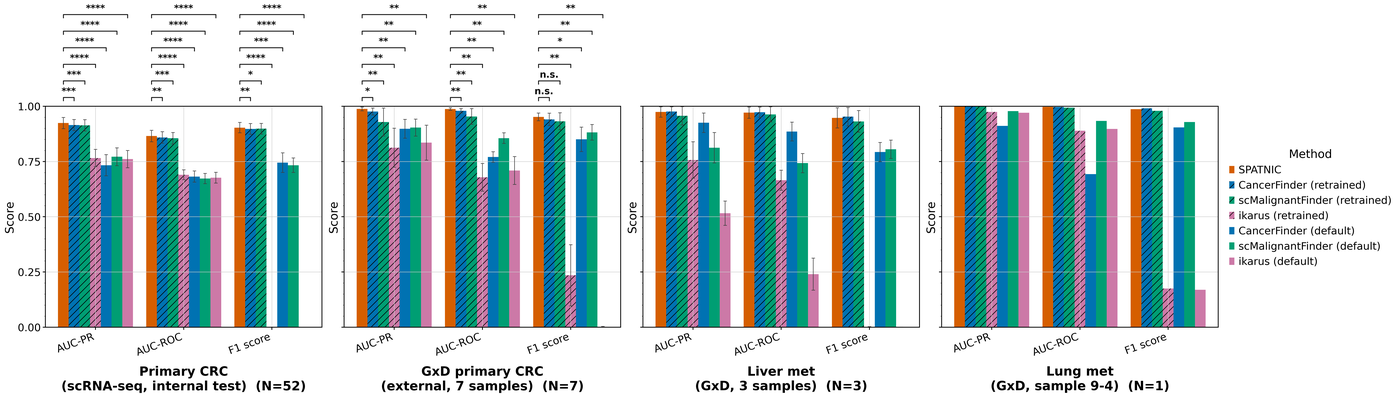

In [ ]:
# Accuracy (4 organs)
Image(str(COMP / "fig2b/fig2b_4organs.png"))

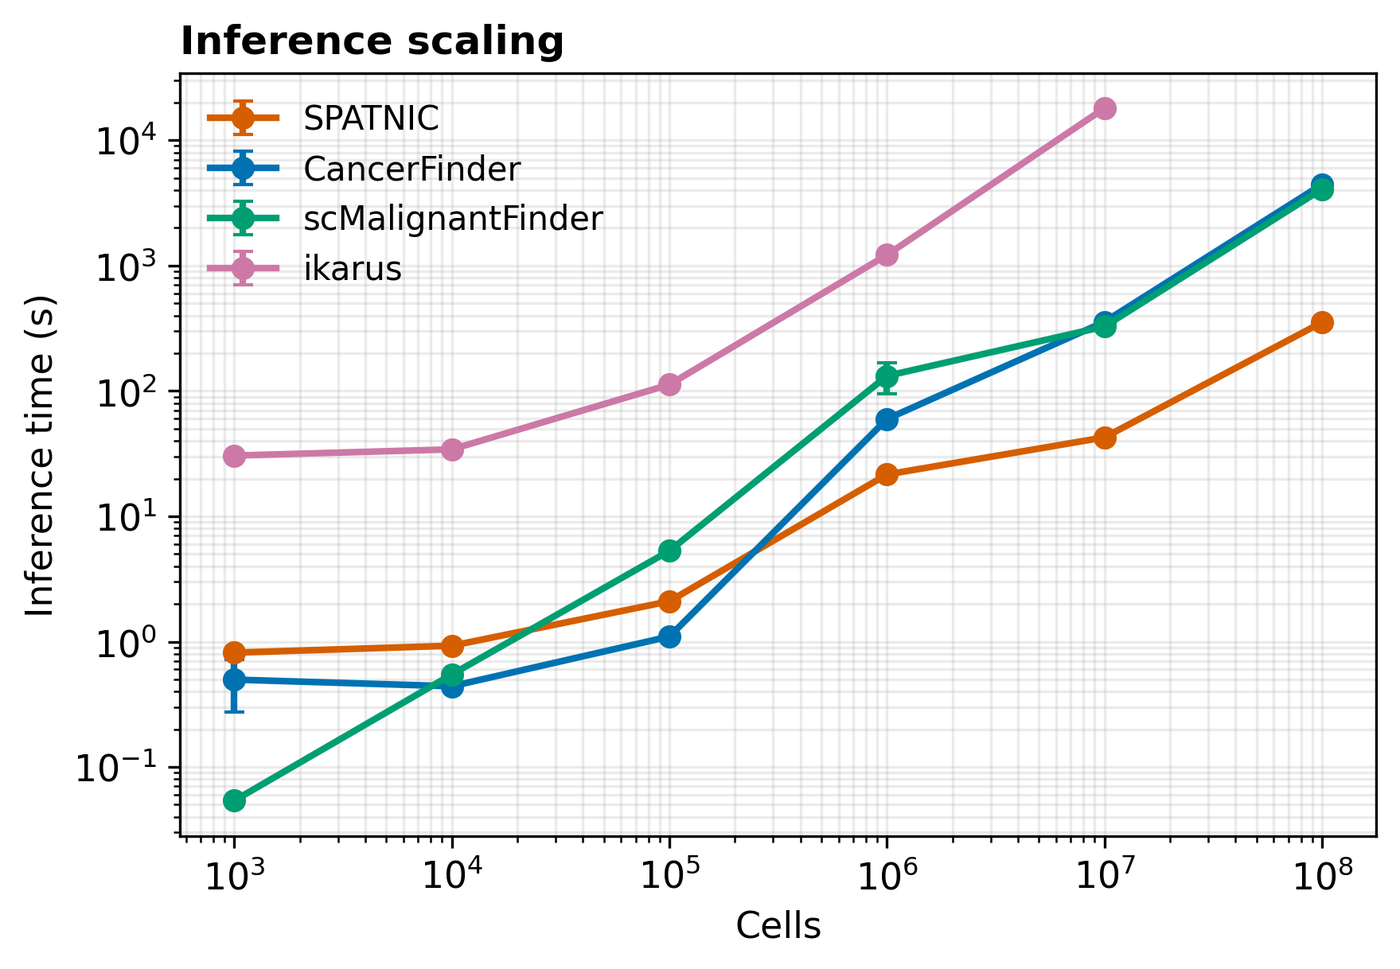

In [ ]:
# Inference time
Image(str(COMP / "fig2e/fig2e.png"))

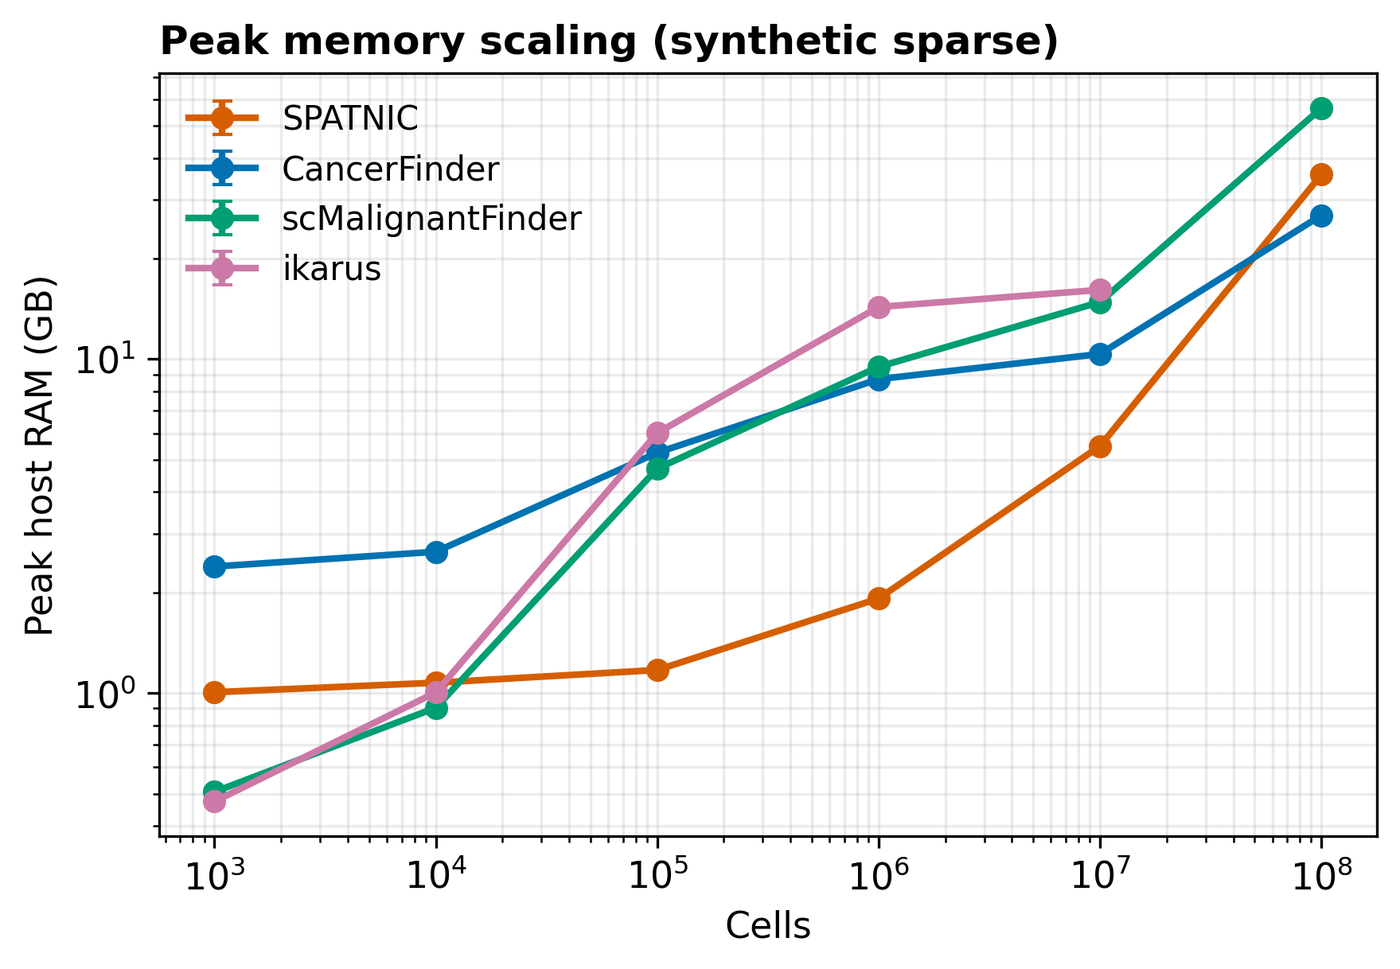

In [ ]:
# Peak host RAM
Image(str(COMP / "fig2e/fig2e_memory_synth.png"))